In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Activation Functions & Losses
This is a jupyter notebook containing **the most used** activations and losses for different types of problems. I try to also explain where and when to use them in a very intuitive way

## Contents

### Supervised Learning
- **Regression Problem** (Real Target)
    - Identity activation, MSE / MAE / Huber loss
- **Binary Classification**
    - Sigmoid / Tanh, Binary Cross-Entropy, KL Divergence
- **Multi-class Classification**
    - Softmax, Categorical Cross-Entropy
    - *Image Classification* — ReLU variants (hidden layers), same output losses
- **Sequence Classification**
    - With RNN/LSTM — Cross-Entropy on output at each timestep
    - With CTC Loss — connectionist alignment, no forced frame-label correspondence

### Structured Output Problems
- **Image Segmentation**
    - Sigmoid/Softmax pixel-wise, BCE + Dice, Focal Loss, Unified Focal Loss
- **Graph Neural Networks**
    - Node-level / edge-level / graph-level tasks
    - Message passing + task-specific loss

### Energy-Based Models
- **Hopfield Networks**
    - Sign / Tanh activation, Energy function

### Bonus: Unsupervised / Self-Supervised
- **Autoencoders**
    - Reconstruction loss (MSE for continuous, BCE for binary inputs)

# Small Caveat - Hidden Layers Activations
In the problems which contain a large number of hidden layers the activation of these neurons are mostly independent of the problem type and it is important to distinguish them from the **output activation functions**

## Hidden layers
To keep it simple they are used so that we are able to make abstractions of the input and to make feature abstraction
- Hidden layers will help to categorize the input features → form representations of the input patterns into clusters as it generalizes over the input patterns 
  - Map: Single neurons → to specific cluster 
    - Weights are adjusted such that inputs belonging to the same category activate similar neurons in the hidden layers 
  - Able to generalize → extracting complex features from input signals
    - Feature abstraction → when the input passes to these layers the network learns to transform raw input into more abstract representations
      - First layers in a network will learn to extract simpler features → deeper layers → more complex features
- Mathematical interpretation → A hidden layer ⟺ non linear transformation to the input data that help reduce the input representations

*Why using hidden layers* → **Universal Approximation Theorem** → a single hidden layer with enough neurons and a nonlinear activation can approximate any continuous function

## Output Neurons
These are the neurons responsible for transforming the output of the hidden 
layers into a representation that is **comparable to the output target** of our 
problem. This is why the activation of these neurons is highly dependent on the 
type of problem we are working on

# Which Activations Are Used in Hidden Layers?

| Activation | Formula | Key Property | When to use |
|---|---|---|---|
| **ReLU** | $\max(0, z)$ | Sparse, fast, no saturation for $z > 0$ | Default choice for most architectures |
| **Leaky ReLU** | $\max(\alpha z, z),\ \alpha \ll 1$ | Avoids dying ReLU (dead neurons) | When ReLU causes dead units |
| **ELU** | $z$ if $z>0$, else $\alpha(e^z - 1)$ | Smooth negative region, zero-centered mean | Deeper networks needing smooth gradients |
| **GELU** | $z \cdot \Phi(z)$ | Probabilistic gating, used in Transformers | Attention-based architectures (BERT, GPT) |
| **Tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | Zero-centered, bounded in $(-1,1)$ | RNNs, LSTMs (hidden state transitions) |

> **Rule of thumb:** Use ReLU by default in feedforward and convolutional networks. 
> Switch to Tanh/sigmoid inside recurrent cells. Use GELU in Transformers.

# Regression Problem (Real Target)
In this case our output varible lives in the continous space, in detail
- Given input ($n \times d$)-dimensional features $x_i \in R^{d}$ with $i = 1, \dots n$
- To each of them we associate a target variable $y_i \in R$ with $i = 1, \dots n$

In this case, we need to have a continous output for each neuron thus, we use the **identity function** as activation, at each neuron we compute:
- **Aggegration of the inputs of the previous layer**: $z^k = \sum_{j=1}^m w_j^k x_j^k$ where $k$ is the index of the kth layer and $m$ is the number of neurons in the kth layer
- **Application of the activation function**: $f(z)=z$
  - Derivative : $f'(z)=1$
- We use the identity function as it gives us unbounded outputs 

## Loss : Mean Squared Errors (MSE)
- The most common loss for regression -> minimize the **average** squared deviation betweeen predictions and targets
- $L = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat y_i)^2$
- Derivative w.r.t. the prediction $\hat{y}_i$: $\frac{\partial L}{\partial \hat{y}_i} = -\frac{2}{n}(y_i - \hat{y}_i)$
  - The negative sign tells us: if we are **under-predicting** ($\hat{y}_i < y_i$), the gradient is negative, so we push $\hat{y}_i$ **upward**
  - The factor $\frac{2}{n}$ is often absorbed into the learning rate in practice, sometimes written as $\frac{1}{n}(y_i - \hat{y}_i)$ by convention

## Architectures
- **Perceptron** — single layer, no hidden units, linear model
- **Adaline** (Adaptive Linear Neuron) : like perceptron but trained with MSE + gradient descent on the linear output (not after activation)
- **MLP** (Multi-Layer Perceptron) multiple hidden layers; identity activation only at the output layer for regression, nonlinear activations (ReLU, tanh) at hidden layers

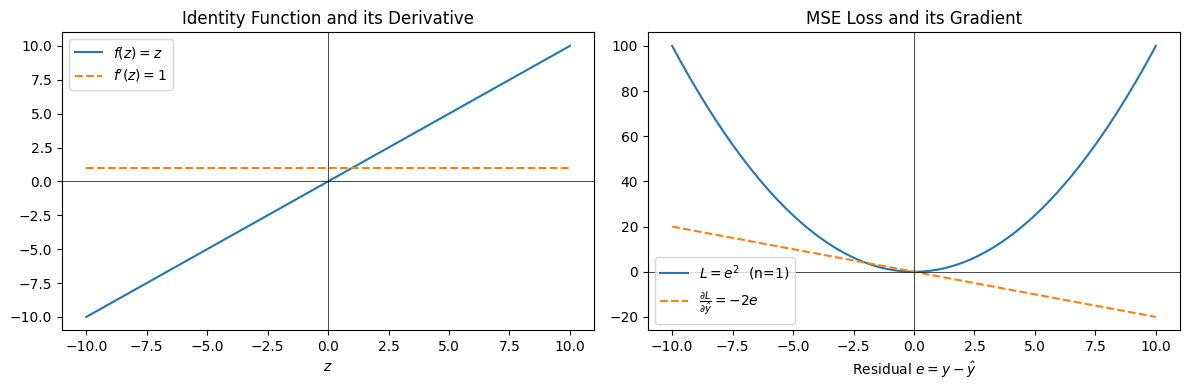

In [4]:
# plot of the identity function and its derivative
# plot of the MSE loss function and its derivative

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

z = np.linspace(-10, 10, 100)
axs[0].plot(z, z, label='$f(z) = z$')
axs[0].plot(z, np.ones_like(z), label="$f'(z) = 1$", linestyle='--')
axs[0].set_title('Identity Function and its Derivative')
axs[0].set_xlabel('$z$')
axs[0].axhline(0, color='k', lw=0.5)
axs[0].axvline(0, color='k', lw=0.5)
axs[0].legend()

e = np.linspace(-10, 10, 100)   # e = y - y_hat (residual)
axs[1].plot(e, e**2,  label='$L = e^2$  (n=1)')
axs[1].plot(e, -2*e,  label="$\\frac{\\partial L}{\\partial \\hat{y}} = -2e$", linestyle='--')
axs[1].set_title('MSE Loss and its Gradient')
axs[1].set_xlabel('Residual $e = y - \\hat{y}$')
axs[1].axhline(0, color='k', lw=0.5)
axs[1].axvline(0, color='k', lw=0.5)
axs[1].legend()

plt.tight_layout()
plt.show()

# Binary Classification

For this type of problem our output variable can take only two possible values, in detail:

- Given input ($n \times d$)-dimensional features $x_i \in \mathbb{R}^{d}$ with $i = 1, \dots, n$
- To each of them we associate a target variable $y_i \in \{0,1\}$ or $y_i \in \{-1,+1\}$

In this case, we need to have an output that mirrors the domain of the target variable. Usually 
we want an activation function that is bounded to the same domain, so that we can threshold and 
get a discrete output. Whether a function should be "squashed" between 0 and 1 depends entirely 
on what that specific layer of the neural network is trying to achieve.
We typically restrict the output to the $(0, 1)$ range only in the **output layer** for specific 
tasks. The possible activation functions we can use are:


## Sigmoid Activation Function $\sigma : \mathbb{R} \to (0,1)$

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$

- It takes any real value as input and outputs values in the range $(0, 1)$. The larger the input 
  (more positive), the closer the output will be to 1, whereas the smaller the input (more 
  negative), the closer the output will be to 0
- Commonly used when we want to predict a **probability** as output
- Differentiable everywhere and provides a smooth gradient
- The derivative $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ has a **maximum of 0.25 at $z=0$** — 
  this small maximum is exactly what causes the vanishing gradient problem in deep networks, as 
  repeated multiplication of values $< 0.25$ shrinks the gradient exponentially as it 
  backpropagates through layers


### Relation with Logistic Regression
- If we train an Adaline model with a sigmoid activation function at the output and minimize 
  binary cross-entropy, we obtain exactly **logistic regression** with parameters trained via 
  (stochastic) gradient descent
- Logistic regression can be seen as a 
  single neuron with a sigmoid output and a log-loss objective


## Hyperbolic Tangent $\tanh : \mathbb{R} \to (-1, +1)$

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}, \qquad \tanh'(z) = 1 - \tanh^2(z)$$

- The larger the input (more positive), the closer the output will be to $+1$, whereas the 
  smaller the input (more negative), the closer the output will be to $-1$, as the domain of 
  the function is in the $(-1, +1)$ range
- The output of the tanh activation is **zero-centered**, we can easily map output values as 
  strongly negative, neutral, or strongly positive
- The derivative $\tanh'(z) = 1 - \tanh^2(z)$ has a **maximum of 1 at $z=0$** and approaches 
  0 as $|z| \to \infty$, it faces the same vanishing gradient problem as sigmoid, but is 
  strictly better due to the larger gradient range and zero-centered outputs
- For binary classification with labels $y \in \{-1, +1\}$, tanh is a natural output activation 
  since its range matches the label domain exactly


## Softplus $: \mathbb{R} \to (0, +\infty)$

$$f(z) = \log(1 + e^z), \qquad f'(z) = \sigma(z) = \frac{1}{1+e^{-z}}$$

- Smooth approximation of the ReLU function (ramp function) — it behaves like $z$ for large 
  positive inputs and like 0 for large negative inputs, but is differentiable everywhere 
  including at $z = 0$
- Note that its derivative **is exactly the sigmoid function** — a useful mathematical identity
- Less commonly used as an output activation for binary classification since its output is 
  unbounded above; more relevant as a hidden layer activation when you need a smooth, 
  always-positive nonlinearity


## Loss Functions

As we are dealing with a binary problem, the most used loss functions are:

### Binary Cross-Entropy (Log-Loss)
**Entropy is the expected value of the surprise** -> the entropy of a random variable is the average level of information (also surprise, or uncertainty) inherent to the variable’s possible outcomes
>  *If a highly likely event occurs, the message carries very little information. On the other hand, if a highly unlikely event occurs, the message is much more informative.*

We want to maximize the log-likelihood of 
the correct label under the predicted probability:


$$L = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1 - y_i)\log(1 - \hat{p}_i) \right]$$

$$\frac{\partial L}{\partial \hat{p}_i} = -\frac{y_i}{\hat{p}_i} + \frac{1 - y_i}{1 - \hat{p}_i}$$

- If combined with the sigmoid, the gradient simplifies to $\hat{p}_i - y_i$ — 
  the prediction error. This clean form is why sigmoid + BCE is the default pairing

### Hinge Loss (for $y \in \{-1, +1\}$ labels)

$$L = \frac{1}{n}\sum_{i=1}^{n} \max\{1 - y_i(\mathbf{w}^\top \mathbf{x}_i + b),\ 0\}$$

- Penalizes not just misclassifications, but also correct predictions that fall within the 
  margin of $1$ -> this is the loss that leads to the **Support Vector Machine (SVM)**
- **Pros:** Focuses entirely on boundary geometry; maximizes margin; outlier-robust
- **Cons:** Does not output probabilities; non-differentiable at $y_i(\mathbf{w}^\top \mathbf{x}_i + b) = 1$

### KL Divergence
We are comparing two probability distributions (*true distribution vs predicted probability*) -> the difference between the distributions can be quantfied by estimating their statistical distance

When we frame binary classification as matching two distributions $P$ (true) and $Q$ (predicted):

$$D_{KL}(P \| Q) = \sum_i P(i) \log \frac{P(i)}{Q(i)}, \qquad \frac{\partial D_{KL}}{\partial Q(i)} = -\frac{P(i)}{Q(i)}$$

- This is basically the difference (distance) between two different probability distributions
  - This is why the outputs do not need to be one hot encoded rather $P$ can be any probability distribution 
    - it treats the target as a distribution, not a point. Note that when 
P
P is one-hot, KL divergence reduces exactly to cross-entropy up to a constant (the entropy of 
P
P, which is 0 for one-hot)
- The intuition for the KL divergence score is that when the probability for an event from P is large, but the probability for the same event in Q is small, there is a large divergence
  - When the probability from P is small and the probability from Q is large, there is also a large divergence, but not as large as the first case
  - **When the score is 0, it suggests that both distributions are identical otherwise the score is positive**
- **Pros:** Generalizes naturally to distributions; used in variational inference and generative models
- **Cons:** Asymmetric ($D_{KL}(P\|Q) \neq D_{KL}(Q\|P)$); undefined when $Q(i) = 0$


## Architectures
- **Perceptron** single neuron, step function output, trained with mistake-driven updates
- **Adaline** + Sigmoid — single neuron, sigmoid output, trained with BCE and gradient descent → logistic regression
- **MLP** multiple hidden layers with ReLU/tanh activations, sigmoid at output neuron


## Notes

**When to avoid the range $(0,1)$ in hidden layers.** In deep networks, due to the vanishing 
gradient problem, we often avoid activations that compress values between 0 and 1 in hidden layers. 
The repeated multiplication of gradient values $< 1$ during backpropagation causes the signal to 
shrink exponentially as it reaches earlier layers — effectively freezing the weights of the first 
layers

To fix this, we use activations such as **ReLU** ($f(z) = \max(0, z)$) which cover a much larger 
range. It outputs $0$ for negative inputs but any positive value for positive inputs

This is why sigmoid and tanh are used **almost exclusively at the output layer** for output range 
transformation, not in the hidden layers of deep networks.

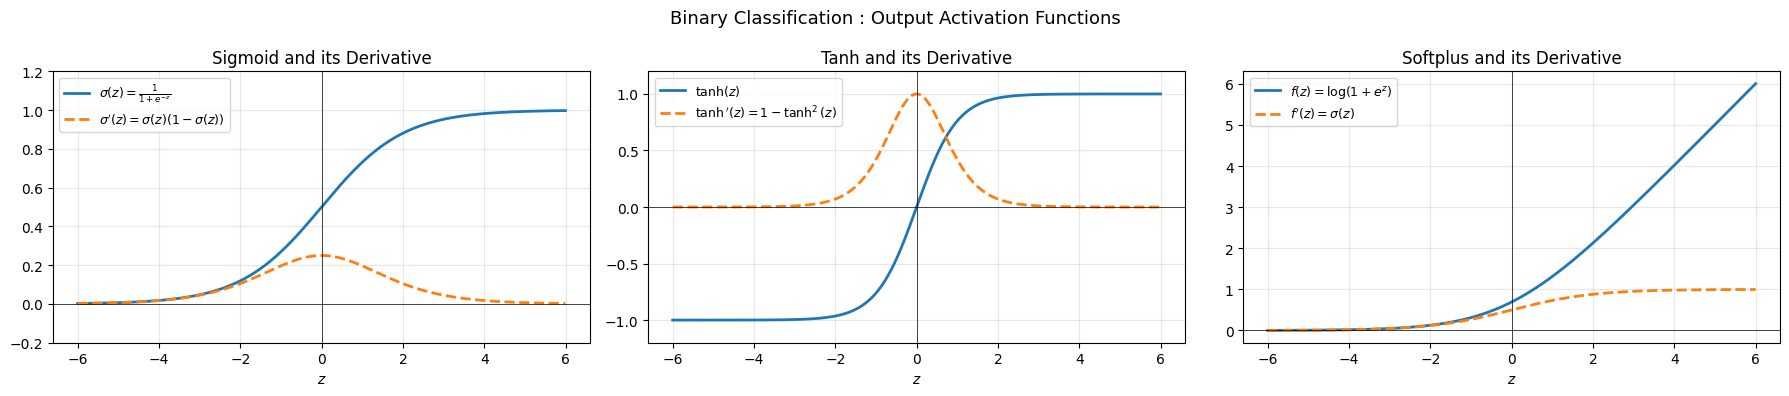

In [8]:
z = np.linspace(-6, 6, 300)

sigmoid   = 1 / (1 + np.exp(-z))
d_sigmoid = sigmoid * (1 - sigmoid)

tanh      = np.tanh(z)
d_tanh    = 1 - np.tanh(z)**2

softplus  = np.log(1 + np.exp(z))
d_softplus = sigmoid

ig, axs = plt.subplots(1, 3, figsize=(18, 4))

configs = [
    (sigmoid, d_sigmoid, r'$\sigma(z) = \frac{1}{1+e^{-z}}$', r"$\sigma'(z) = \sigma(z)(1-\sigma(z))$", 'Sigmoid',(0,1)),
    (tanh, d_tanh, r'$\tanh(z)$', r"$\tanh'(z) = 1 - \tanh^2(z)$", 'Tanh', (-1, 1)),
    (softplus, d_softplus, r'$f(z) = \log(1 + e^z)$', r"$f'(z) = \sigma(z)$", 'Softplus',  None),
]

for ax, (f, df, label_f, label_df, title, ylim) in zip(axs, configs):
    ax.plot(z,f,lw=2,label=label_f)
    ax.plot(z, df,lw=2, linestyle='--',label=label_df)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f'{title} and its Derivative', fontsize=12)
    ax.set_xlabel('$z$')
    if ylim:
        ax.set_ylim(ylim[0] - 0.2, ylim[1] + 0.2)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Binary Classification : Output Activation Functions', fontsize=13)
plt.tight_layout()
plt.show()